In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     Bidirectional, SpatialDropout1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [2]:
# ─────────────────────────────────────────────
# 1. KONFIGURASI
# ─────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

MAX_VOCAB   = 15000   # ukuran vocabulary
MAX_LEN     = 100     # panjang sekuens maksimum
EMBED_DIM   = 128     # dimensi embedding
LSTM_UNITS  = 64      # unit LSTM
BATCH_SIZE  = 128
EPOCHS      = 20
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1

DATA_PATH   = "/mnt/user-data/uploads/dataset_clean_final.csv"
OUTPUT_DIR  = "/mnt/user-data/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# 2. LOAD & PREPROCESSING DATA
# ─────────────────────────────────────────────
print("=" * 55)
print("  LSTM CLASSIFIER - DETEKSI KOMENTAR JUDI ONLINE")
print("=" * 55)

df = pd.read_csv("../Dataset/dataset_clean_final.csv")

df.columns = df.columns.str.strip()
df = df[['text', 'label']].dropna()
df['text'] = df['text'].astype(str)

print(f"\n[1] Dataset dimuat: {len(df):,} baris")
print(f"    Label 0 (bukan judi) : {(df['label']==0).sum():,}")
print(f"    Label 1 (judi)       : {(df['label']==1).sum():,}")

print(df.head())


  LSTM CLASSIFIER - DETEKSI KOMENTAR JUDI ONLINE

[1] Dataset dimuat: 70,379 baris
    Label 0 (bukan judi) : 62,202
    Label 1 (judi)       : 8,177
                                                text  label
0  makin yakin habis baca review lain tentang vic...      1
1  paling suka model h2 smiling_face_with_heart e...      0
2                mobilnya sudah hancur pleading_face      0
3                manut88benar2 bikin aku jadi sultan      1
4             semoga lekas recover mobilnya mas dipo      0


In [3]:
# Fungsi pembersihan teks Bahasa Indonesia
EMOJI_PATTERN = re.compile(
    "["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F9FF"
    u"\U00002700-\U000027BF"
    "]+", flags=re.UNICODE
)

In [5]:
def clean_text(text):
    text = text.lower()
    text = EMOJI_PATTERN.sub(' ', text)
    # hapus URL
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # hapus mention & hashtag
    text = re.sub(r'[@#]\w+', '', text)
    # hapus angka berlebih (tapi pertahankan jika bagian kata seperti "slot88")
    text = re.sub(r'\b\d{5,}\b', '', text)
    # hapus karakter khusus kecuali huruf & spasi
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # normalisasi spasi
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)


In [6]:

# ─────────────────────────────────────────────
# 3. TOKENISASI & PADDING
# ─────────────────────────────────────────────
print("\n[2] Tokenisasi teks...")

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text_clean'])

sequences = tokenizer.texts_to_sequences(df['text_clean'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values

vocab_size = min(len(tokenizer.word_index) + 1, MAX_VOCAB)
print(f"    Vocabulary size  : {vocab_size:,}")
print(f"    Input shape      : {X.shape}")


[2] Tokenisasi teks...
    Vocabulary size  : 15,000
    Input shape      : (70379, 100)


In [7]:
# ─────────────────────────────────────────────
# 4. SPLIT DATA
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=SEED, stratify=y_train
)

print(f"\n[3] Split data:")
print(f"    Train : {len(X_train):,}")
print(f"    Val   : {len(X_val):,}")
print(f"    Test  : {len(X_test):,}")

# Class weights untuk menangani imbalanced data
class_weights_arr = compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}
print(f"\n    Class weights: {class_weight}")



[3] Split data:
    Train : 49,265
    Val   : 7,038
    Test  : 14,076

    Class weights: {0: np.float64(0.5657311499506212), 1: np.float64(4.30337176799441)}


In [8]:
# ─────────────────────────────────────────────
# 5. ARSITEKTUR MODEL LSTM
# ─────────────────────────────────────────────
print("\n[4] Membangun model Bidirectional LSTM...")

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
              input_length=MAX_LEN, mask_zero=True),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True, dropout=0.3,
                       recurrent_dropout=0.2)),
    Bidirectional(LSTM(LSTM_UNITS // 2, dropout=0.3, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()



[4] Membangun model Bidirectional LSTM...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ─────────────────────────────────────────────
# 6. TRAINING
# ─────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_auc', patience=4, restore_best_weights=True,
                  mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                      min_lr=1e-6, verbose=1)
]

print("\n[5] Memulai training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)



[5] Memulai training...
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 620s 2s/step - accuracy: 0.9361 - auc: 0.9742 - loss: 0.2082 - precision: 0.6659 - recall: 0.9039 - val_accuracy: 0.9828 - val_auc: 0.9916 - val_loss: 0.0713 - val_precision: 0.9020 - val_recall: 0.9560 - learning_rate: 0.0010
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 396s 1s/step - accuracy: 0.9885 - auc: 0.9965 - loss: 0.0538 - precision: 0.9264 - recall: 0.9783 - val_accuracy: 0.9861 - val_auc: 0.9922 - val_loss: 0.0578 - val_precision: 0.9176 - val_recall: 0.9670 - learning_rate: 0.0010
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 422s 1s/step - accuracy: 0.9925 - auc: 0.9987 - loss: 0.0323 - precision: 0.9505 - recall: 0.9869 - val_accuracy: 0.9851 - val_auc: 0.9911 - val_loss: 0.0647 - val_precision: 0.9121 - val_recall: 0.9645 - learning_rate: 0.0010
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9946 - auc: 0.9994 - loss: 0.0222 - precision: 0.9630 - recall: 0.9917
Epoch 4: ReduceLROnPlateau reducing le

In [10]:

# ─────────────────────────────────────────────
# 7. EVALUASI
# ─────────────────────────────────────────────
print("\n[6] Evaluasi pada data test...")
y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred,
      target_names=['Bukan Judi (0)', 'Judi (1)']))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score : {roc_auc:.4f}")



[6] Evaluasi pada data test...

── Classification Report ──
                precision    recall  f1-score   support

Bukan Judi (0)       1.00      0.99      0.99     12441
      Judi (1)       0.93      0.97      0.95      1635

      accuracy                           0.99     14076
     macro avg       0.96      0.98      0.97     14076
  weighted avg       0.99      0.99      0.99     14076

ROC-AUC Score : 0.9953



[7] Membuat visualisasi...


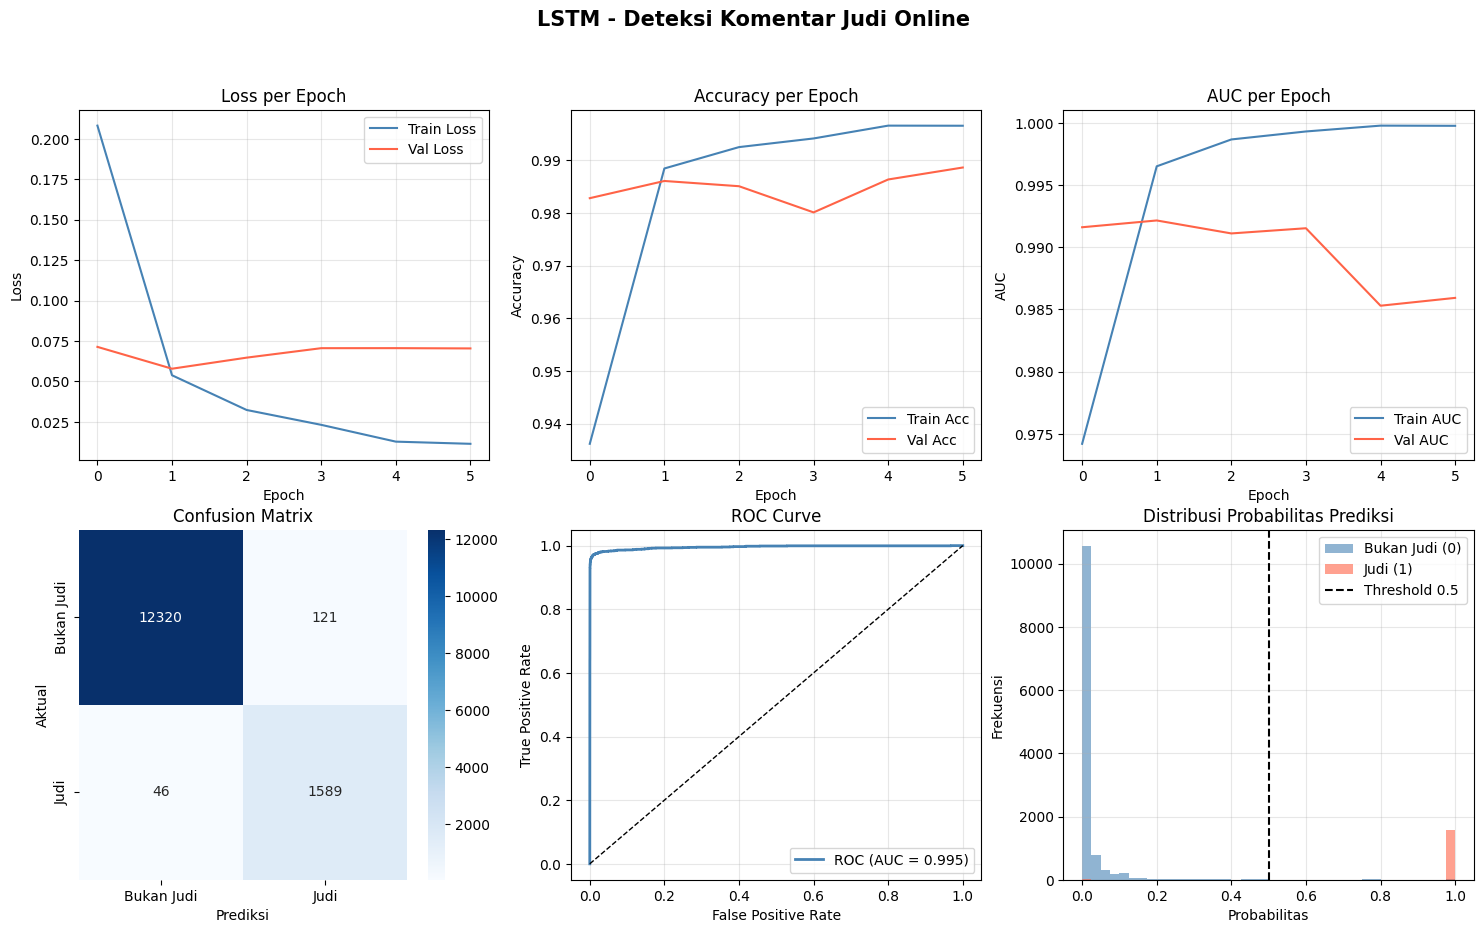

In [13]:
# ─────────────────────────────────────────────
# 8. VISUALISASI
# ─────────────────────────────────────────────
print("\n[7] Membuat visualisasi...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("LSTM - Deteksi Komentar Judi Online", fontsize=15, fontweight='bold')

# (a) Training curves - Loss
axes[0,0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0,0].plot(history.history['val_loss'], label='Val Loss', color='tomato')
axes[0,0].set_title('Loss per Epoch')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# (b) Training curves - Accuracy
axes[0,1].plot(history.history['accuracy'], label='Train Acc', color='steelblue')
axes[0,1].plot(history.history['val_accuracy'], label='Val Acc', color='tomato')
axes[0,1].set_title('Accuracy per Epoch')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# (c) Training curves - AUC
axes[0,2].plot(history.history['auc'], label='Train AUC', color='steelblue')
axes[0,2].plot(history.history['val_auc'], label='Val AUC', color='tomato')
axes[0,2].set_title('AUC per Epoch')
axes[0,2].set_xlabel('Epoch'); axes[0,2].set_ylabel('AUC')
axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

# (d) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['Bukan Judi', 'Judi'],
            yticklabels=['Bukan Judi', 'Judi'])
axes[1,0].set_title('Confusion Matrix')
axes[1,0].set_ylabel('Aktual'); axes[1,0].set_xlabel('Prediksi')

# (e) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1,1].plot(fpr, tpr, color='steelblue', lw=2,
               label=f'ROC (AUC = {roc_auc:.3f})')
axes[1,1].plot([0,1], [0,1], 'k--', lw=1)
axes[1,1].set_title('ROC Curve')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

# (f) Distribusi Probabilitas Prediksi
axes[1,2].hist(y_prob[y_test==0], bins=40, alpha=0.6,
               color='steelblue', label='Bukan Judi (0)')
axes[1,2].hist(y_prob[y_test==1], bins=40, alpha=0.6,
               color='tomato', label='Judi (1)')
axes[1,2].axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
axes[1,2].set_title('Distribusi Probabilitas Prediksi')
axes[1,2].set_xlabel('Probabilitas'); axes[1,2].set_ylabel('Frekuensi')
axes[1,2].legend(); axes[1,2].grid(alpha=0.3)

plt.show()
# plt.tight_layout()
# plot_path = os.path.join(OUTPUT_DIR, "lstm_hasil_evaluasi.png")
# plt.savefig(plot_path, dpi=150, bbox_inches='tight')
# plt.close()
# print(f"    Plot disimpan: {plot_path}")


In [14]:
# ─────────────────────────────────────────────
# 9. SIMPAN MODEL
# ─────────────────────────────────────────────
model_path = os.path.join(OUTPUT_DIR, "lstm_judi_model.keras")
model.save(model_path)
print(f"\n[8] Model disimpan: {model_path}")


[8] Model disimpan: /mnt/user-data/outputs\lstm_judi_model.keras


In [15]:
# ─────────────────────────────────────────────
# 10. FUNGSI PREDIKSI (DEMO)
# ─────────────────────────────────────────────
def predict_komentar(teks_list):
    """Prediksi komentar baru."""
    cleaned = [clean_text(t) for t in teks_list]
    seqs = tokenizer.texts_to_sequences(cleaned)
    padded = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
    probs = model.predict(padded, verbose=0).flatten()
    results = []
    for teks, prob in zip(teks_list, probs):
        label = "🎰 JUDI" if prob >= 0.5 else "✅ BUKAN JUDI"
        results.append({
            "komentar"   : teks[:60] + "..." if len(teks) > 60 else teks,
            "prediksi"   : label,
            "probabilitas": f"{prob:.2%}"
        })
    return pd.DataFrame(results)

# Demo prediksi
contoh = [
    "Daftar sekarang dan dapatkan bonus deposit 100% tanpa syarat!",
    "Makasih resepnya kak, enak banget dicoba di rumah",
    "Link alternatif slot88 gacor hari ini, winrate tinggi!",
    "Semoga cepet sembuh ya, get well soon!",
    "Bergabung sekarang, jackpot menanti kamu!",
    "Wah pemandangannya bagus banget, dimana nih lokasiknya?",
]

print("\n── Demo Prediksi ──")
hasil = predict_komentar(contoh)
print(hasil.to_string(index=False))

print("\n✅ Semua proses selesai!")
print(f"   Model   : {model_path}")
print(f"   Grafik  : {plot_path}")



── Demo Prediksi ──
                                                       komentar     prediksi probabilitas
Daftar sekarang dan dapatkan bonus deposit 100% tanpa syarat...       🎰 JUDI       99.97%
              Makasih resepnya kak, enak banget dicoba di rumah ✅ BUKAN JUDI       28.16%
         Link alternatif slot88 gacor hari ini, winrate tinggi!       🎰 JUDI       96.02%
                         Semoga cepet sembuh ya, get well soon! ✅ BUKAN JUDI        0.12%
                      Bergabung sekarang, jackpot menanti kamu!       🎰 JUDI       99.90%
        Wah pemandangannya bagus banget, dimana nih lokasiknya? ✅ BUKAN JUDI        9.90%

✅ Semua proses selesai!
   Model   : /mnt/user-data/outputs\lstm_judi_model.keras
   Grafik  : /mnt/user-data/outputs\lstm_hasil_evaluasi.png
